In [1]:
import os
import sys

# 현재 작업 디렉토리 확인해보고
print("CWD:", os.getcwd())

# notebooks/ 에서 한 단계 위(프로젝트 루트)로 올라가기
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("PROJECT_ROOT:", PROJECT_ROOT)

# sys.path 에 프로젝트 루트가 없으면 추가
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print("Added to sys.path")


CWD: c:\Users\user\Desktop\project\scalp-vision-agent\notebooks
PROJECT_ROOT: c:\Users\user\Desktop\project\scalp-vision-agent
Added to sys.path


In [2]:
import torch
from torch.utils.data import DataLoader
from torch import optim

from src.config import MASTER_INDEX_CSV
from src.cnn.dataset import ScalpDataset
from src.cnn.models import MultiHeadResNet18
from src.cnn.utils import labels_dict_to_tensor
from src.cnn.losses import multihead_ce_loss
from src.cnn.train import get_device, train_one_epoch, evaluate_one_epoch, train_model


In [8]:
device = get_device()
device


device(type='cuda')

In [3]:
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-4


In [4]:
import torchvision.transforms as T

train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05,
    ),
    T.ToTensor(),
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])


In [5]:
from torch.utils.data import Subset

train_dataset = ScalpDataset(index_csv=MASTER_INDEX_CSV, split="train", transforms=train_transform)
val_dataset   = ScalpDataset(index_csv=MASTER_INDEX_CSV, split="val",   transforms=val_transform)

print(len(train_dataset), len(val_dataset))


67588 23568


In [6]:
USE_SUBSET = False   # overfit 테스트: True, 전체 학습: False

if USE_SUBSET:
    subset_indices = list(range(100))  
    train_dataset_small = Subset(train_dataset, subset_indices)
    train_loader = DataLoader(train_dataset_small, batch_size=BATCH_SIZE, shuffle=True)
else:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [9]:
model = MultiHeadResNet18()
model.to(device)

from torch.optim import AdamW
optimizer = AdamW(
    model.parameters(),
    lr=LR,           # 기존 lr 그대로 (너가 쓰던 값)
    weight_decay=1e-4, # 새로 추가
)


In [10]:
batch = next(iter(train_loader))

print("type:", type(batch["image"]))
print("shape:", batch["image"].shape)
print("dtype:", batch["image"].dtype)
print("device:", batch["image"].device)


type: <class 'torch.Tensor'>
shape: torch.Size([32, 3, 224, 224])
dtype: torch.float32
device: cpu


In [11]:
len(train_dataset), len(train_loader), len(val_dataset), len(val_loader)


(67588, 2113, 23568, 737)

In [12]:
# 셀 1: 기본 상수와 import

import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader

# 멀티헤드 이름 (이미 위에서 정의했어도 다시 정의해도 무방)
HEAD_NAMES = ["value_1", "value_2", "value_3", "value_4", "value_5", "value_6"]

NUM_HEADS = len(HEAD_NAMES)  # 6
NUM_CLASSES = 4              # 각 head는 0~3 등급


In [13]:
# 셀 2: DataLoader 배치에서 image, labels 텐서만 안전하게 추출하는 함수

from typing import Any, Tuple

def extract_images_and_labels(batch: Any) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    DataLoader가 반환하는 batch에서
    - images: [B, 3, 224, 224] 텐서
    - labels: [B, NUM_HEADS] 텐서
    를 추출해주는 유틸 함수.

    batch는 dict 또는 (images, labels, ...) 튜플일 수 있다.
    labels가 텐서 혹은 dict일 수 있는 상황을 모두 처리한다.
    """
    # 1) batch 타입에 따른 분기
    if isinstance(batch, dict):
        # 케이스 A: dict 배치
        if "image" not in batch:
            raise KeyError("batch dict에 'image' 키가 없습니다.")
        images = batch["image"]

        if "labels" not in batch:
            # 예외적으로 labels 키가 없으면 첫 두 개 텐서를 image/labels로 가정
            tensor_values = [v for v in batch.values() if isinstance(v, torch.Tensor)]
            if len(tensor_values) < 2:
                raise ValueError("batch dict에서 labels 텐서를 찾을 수 없습니다.")
            labels_obj = tensor_values[1]
        else:
            labels_obj = batch["labels"]

    elif isinstance(batch, (list, tuple)):
        # 케이스 B: (images, labels, ...) 튜플
        if len(batch) < 2:
            raise ValueError("batch 튜플 길이가 2 미만입니다. images, labels를 둘 다 포함해야 합니다.")
        images, labels_obj = batch[0], batch[1]

    else:
        raise TypeError(f"지원하지 않는 batch 타입입니다: {type(batch)}")

    if not isinstance(images, torch.Tensor):
        raise TypeError(f"images가 torch.Tensor가 아닙니다: {type(images)}")

    # 2) labels_obj 타입에 따른 처리
    if isinstance(labels_obj, torch.Tensor):
        # 이미 [B, NUM_HEADS] 형태라고 가정
        labels = labels_obj
    elif isinstance(labels_obj, dict):
        # 예: {"value_1": tensor([..]), ..., "value_6": tensor([..])}
        value_keys = [k for k in labels_obj.keys() if k.startswith("value_")]
        if value_keys:
            # "value_1"~"value_6" 순으로 정렬
            value_keys = sorted(value_keys, key=lambda k: int(k.split("_")[1]))
            tensors = [labels_obj[k] for k in value_keys]
        else:
            # 혹시 value_ 키가 없다면 그냥 키 이름으로 정렬
            tensors = [labels_obj[k] for k in sorted(labels_obj.keys())]

        # 각 텐서는 [B] 라고 가정하고, [NUM_HEADS, B] → [B, NUM_HEADS] 로 스택
        tensors = [t if t.ndim == 1 else t.view(-1) for t in tensors]
        labels = torch.stack(tensors, dim=1)
    else:
        raise TypeError(f"labels_obj가 텐서도 dict도 아닙니다: {type(labels_obj)}")

    # 최종적으로 [B, NUM_HEADS]인지 한 번 더 체크
    if labels.ndim != 2 or labels.size(1) != NUM_HEADS:
        raise ValueError(
            f"labels의 shape가 예상과 다릅니다: {labels.shape}, "
            f"기대한 형상은 [B, {NUM_HEADS}] 입니다."
        )

    return images, labels


In [14]:
# 셀 3: train_loader를 한 번 훑어서 각 head별 class count 계산

head_class_counts = torch.zeros((NUM_HEADS, NUM_CLASSES), dtype=torch.long)

model.eval()
with torch.no_grad():
    for batch in train_loader:
        images, labels = extract_images_and_labels(batch)  # labels: [B, 6]
        labels = labels.long()

        for h in range(NUM_HEADS):
            head_labels = labels[:, h]  # [B]
            for c in range(NUM_CLASSES):
                head_class_counts[h, c] += (head_labels == c).sum()

head_class_counts


tensor([[55609,  4435,  5457,  2087],
        [13970, 26538, 23584,  3496],
        [20658, 29811, 12874,  4245],
        [64482,  2124,   702,   280],
        [41495, 15617,  8565,  1911],
        [51312, 12185,  3402,   689]])

In [15]:
# 셀 4: head_class_counts를 바탕으로 inverse-frequency 기반 class weight 계산

# 0인 곳이 있다면 division by zero를 막기 위해 epsilon 더해줌
eps = 1e-6

# 각 head별 총 샘플 수: [NUM_HEADS, 1]
head_totals = head_class_counts.sum(dim=1, keepdim=True).float() + eps

# class frequency: 각 head별 [NUM_HEADS, NUM_CLASSES]
class_freq = head_class_counts.float() / head_totals

# inverse frequency: 자주 나오는 class는 작게, 희소한 class는 크게
inv_freq = 1.0 / (class_freq + eps)

# head별로 평균이 1이 되도록 정규화 (scale 안정화)
head_class_weights = inv_freq / inv_freq.mean(dim=1, keepdim=True)

head_class_weights


tensor([[0.0794, 0.9956, 0.8092, 2.1158],
        [0.6542, 0.3444, 0.3875, 2.6140],
        [0.4900, 0.3395, 0.7862, 2.3843],
        [0.0113, 0.3436, 1.0394, 2.6057],
        [0.1324, 0.3518, 0.6414, 2.8745],
        [0.0422, 0.1778, 0.6367, 3.1434]])

In [16]:
# 셀 5: 멀티헤드 weighted CE loss + accuracy 함수

def multihead_weighted_ce_loss(
    logits: torch.Tensor,        # [B, NUM_HEADS, NUM_CLASSES]
    targets: torch.Tensor,       # [B, NUM_HEADS]
    class_weights: torch.Tensor, # [NUM_HEADS, NUM_CLASSES]
) -> torch.Tensor:
    """
    head마다 다른 class weight를 적용하는 멀티헤드 CE loss.

    - logits[h]에 대해 class_weights[h]를 weight로 사용
    - head별 loss 평균을 최종 loss로 사용
    """
    B, H, C = logits.shape
    assert H == NUM_HEADS and C == NUM_CLASSES, f"Unexpected logits shape: {logits.shape}"

    loss = 0.0
    for h in range(H):
        weight_h = class_weights[h].to(logits.device)
        loss_h = F.cross_entropy(
            logits[:, h, :],      # [B, C]
            targets[:, h],        # [B]
            weight=weight_h,      # [C]
        )
        loss = loss + loss_h

    loss = loss / H
    return loss


def compute_multihead_accuracy(
    logits: torch.Tensor,   # [B, NUM_HEADS, NUM_CLASSES]
    targets: torch.Tensor,  # [B, NUM_HEADS]
) -> float:
    """
    멀티헤드 전체에 대해 단순 평균 정확도 계산.
    (모든 head / 모든 샘플 기준으로 정확도 평균)
    """
    preds = logits.argmax(dim=-1)  # [B, NUM_HEADS]
    acc = (preds == targets).float().mean().item()
    return acc


In [17]:
# 셀 6: 검증용 evaluate 함수 (전체 loss/acc + head별 loss/acc)

def evaluate_one_epoch_with_heads(
    model: torch.nn.Module,
    dataloader: DataLoader,
    device: torch.device,
) -> tuple[float, float, list[float], list[float]]:
    """
    - 전체 val_loss, val_acc
    - head별 loss/acc 리스트까지 함께 반환
    """
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    head_losses = torch.zeros(NUM_HEADS, dtype=torch.float32)
    head_accs = torch.zeros(NUM_HEADS, dtype=torch.float32)

    with torch.no_grad():
        for batch in dataloader:
            images, labels = extract_images_and_labels(batch)
            images = images.to(device)
            labels = labels.long().to(device)  # [B, NUM_HEADS]

            logits = model(images)  # [B, NUM_HEADS, NUM_CLASSES]

            # 멀티헤드 CE (unweighted)로 평가
            B, H, C = logits.shape
            loss = 0.0
            for h in range(H):
                loss_h = F.cross_entropy(logits[:, h, :], labels[:, h])
                loss = loss + loss_h
            loss = loss / H

            batch_acc = compute_multihead_accuracy(logits, labels)

            total_loss += loss.item()
            total_acc += batch_acc
            n_batches += 1

            # head별 loss/acc 계산
            for h in range(H):
                head_logits = logits[:, h, :]
                head_targets = labels[:, h]
                loss_h = F.cross_entropy(head_logits, head_targets)
                preds_h = head_logits.argmax(dim=-1)
                acc_h = (preds_h == head_targets).float().mean().item()

                head_losses[h] += loss_h.item()
                head_accs[h] += acc_h

    avg_loss = total_loss / n_batches
    avg_acc = total_acc / n_batches

    head_losses /= n_batches
    head_accs /= n_batches

    return avg_loss, avg_acc, head_losses.tolist(), head_accs.tolist()


In [18]:
# 셀 7: E3 실험 - class weight 적용 멀티헤드 학습 (예: 3 epoch)

import copy

# 기존 model을 그대로 덮어쓰고 싶지 않으면 복사해서 사용
model_e3 = copy.deepcopy(model).to(device)

optimizer_e3 = torch.optim.AdamW(
    model_e3.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

num_epochs = 3

history_e3 = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_head_loss": [],
    "val_head_acc": [],
}

best_val_loss = float("inf")

for epoch in range(1, num_epochs + 1):
    print(f"\n===== [E3] Epoch {epoch} / {num_epochs} =====")

    # ----- train -----
    model_e3.train()
    running_loss = 0.0
    running_acc = 0.0
    n_batches = 0

    for batch in train_loader:
        images, labels = extract_images_and_labels(batch)
        images = images.to(device)
        labels = labels.long().to(device)

        optimizer_e3.zero_grad()
        logits = model_e3(images)

        loss = multihead_weighted_ce_loss(
            logits=logits,
            targets=labels,
            class_weights=head_class_weights.to(device),
        )

        loss.backward()
        optimizer_e3.step()

        batch_acc = compute_multihead_accuracy(logits, labels)

        running_loss += loss.item()
        running_acc += batch_acc
        n_batches += 1

    train_loss = running_loss / n_batches
    train_acc = running_acc / n_batches

    # ----- validation -----
    val_loss, val_acc, val_head_losses, val_head_accs = evaluate_one_epoch_with_heads(
        model=model_e3,
        dataloader=val_loader,
        device=device,
    )

    history_e3["train_loss"].append(train_loss)
    history_e3["train_acc"].append(train_acc)
    history_e3["val_loss"].append(val_loss)
    history_e3["val_acc"].append(val_acc)
    history_e3["val_head_loss"].append(val_head_losses)
    history_e3["val_head_acc"].append(val_head_accs)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"  ↳ Best model updated! val_loss={val_loss:.4f}")

    # 로그 출력
    print(
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    print("  [Val per-head metrics]")
    for name, h_loss, h_acc in zip(HEAD_NAMES, val_head_losses, val_head_accs):
        print(f"    - {name}: loss={h_loss:.4f}, acc={h_acc:.4f}")



===== [E3] Epoch 1 / 3 =====
  ↳ Best model updated! val_loss=0.8329
train_loss=1.0540, train_acc=0.5928 | val_loss=0.8329, val_acc=0.6478
  [Val per-head metrics]
    - value_1: loss=1.0130, acc=0.5685
    - value_2: loss=1.0918, acc=0.4835
    - value_3: loss=0.8089, acc=0.6505
    - value_4: loss=0.5645, acc=0.8097
    - value_5: loss=0.7777, acc=0.6921
    - value_6: loss=0.7416, acc=0.6825

===== [E3] Epoch 2 / 3 =====
  ↳ Best model updated! val_loss=0.8061
train_loss=0.9712, train_acc=0.6290 | val_loss=0.8061, val_acc=0.6646
  [Val per-head metrics]
    - value_1: loss=0.8033, acc=0.6734
    - value_2: loss=1.1892, acc=0.4456
    - value_3: loss=0.7536, acc=0.6830
    - value_4: loss=0.6180, acc=0.7740
    - value_5: loss=0.7475, acc=0.6923
    - value_6: loss=0.7253, acc=0.7193

===== [E3] Epoch 3 / 3 =====
train_loss=0.9448, train_acc=0.6408 | val_loss=0.9025, val_acc=0.6148
  [Val per-head metrics]
    - value_1: loss=0.9495, acc=0.6149
    - value_2: loss=1.0443, acc=0.5035

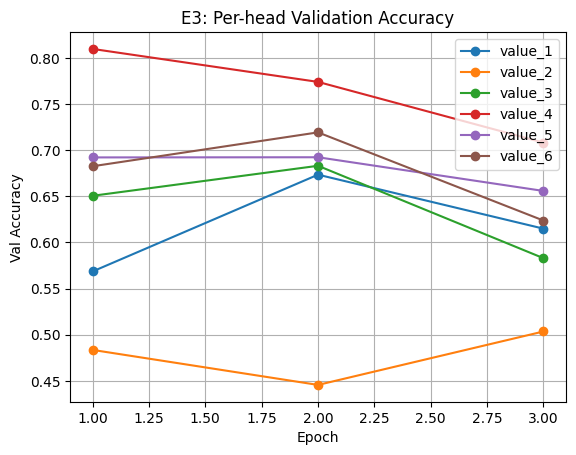

In [19]:
# 셀 8: head별 val accuracy 추이를 간단히 시각화 (선택)

import matplotlib.pyplot as plt

epochs = range(1, len(history_e3["val_head_acc"]) + 1)

plt.figure()
for h, name in enumerate(HEAD_NAMES):
    acc_list = [epoch_head_acc[h] for epoch_head_acc in history_e3["val_head_acc"]]
    plt.plot(epochs, acc_list, marker="o", label=name)

plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.title("E3: Per-head Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------

좋아, 1번 컴퓨터 E3 실험 결과 깔끔하게 **LOG.md용 정리**해줄게.
바로 붙여넣기 좋게 마크다운으로 쓸게.

---

## [E3] Class-weighted Multi-head CNN 실험 정리

### 1. 실험 목적

* **목표:** 멀티헤드 CNN에서 **클래스 불균형을 완화**하기 위해, 각 head에 **class weight**를 적용했을 때 성능 변화를 확인.
* **관심 포인트:**

  * 전체 val_loss / val_acc 개선 여부
  * head별 성능 특히 **value_2(피지)** 개선 여부
  * 과적합 양상(3 epoch 기준)

---

### 2. 실험 설정 (요약)

* 모델: 기존 멀티헤드 CNN(E2와 동일 아키텍처)
* 출력: 각 head가 4-class 분류 (value_1~6, 0~3)
* 손실함수: CrossEntropy + **class weight 적용(E3)**
* Epoch: **3**
* Train/Val split, 이미지 전처리, 옵티마이저/러닝레이트 등은 **E2와 동일**

---

### 3. 전체 성능 지표

| Epoch | train_loss | train_acc | val_loss | val_acc | 비고                |
| ----: | ---------: | --------: | -------: | ------: | ----------------- |
|     1 |     1.0540 |    0.5928 |   0.8329 |  0.6478 | Best model (1차)   |
|     2 |     0.9712 |    0.6290 |   0.8061 |  0.6646 | **Best model 최종** |
|     3 |     0.9448 |    0.6408 |   0.9025 |  0.6148 | val 성능 하락 시작      |

* **Best epoch:** 2 (val_loss 최소, val_acc 최대)

---

### 4. Head별 Validation 성능 (Best epoch = 2 기준)

Epoch 2에서의 **per-head val_loss / val_acc**:

* **value_1 (각질)**

  * loss **0.8033**, acc **0.6734**
* **value_2 (피지)**

  * loss **1.1892**, acc **0.4456**
* **value_3 (모낭 사이 홍반)**

  * loss **0.7536**, acc **0.6830**
* **value_4 (모낭 홍반/농포)**

  * loss **0.6180**, acc **0.7740**
* **value_5 (비듬)**

  * loss **0.7475**, acc **0.6923**
* **value_6 (탈모)**

  * loss **0.7253**, acc **0.7193**

그래프(E3: Per-head Validation Accuracy)에서 확인되는 패턴:

* 대부분의 head가 **Epoch 2에서 peak**를 찍고, Epoch 3에서 하락.
* **value_2**는 1→2에서 오히려 살짝 내려갔다가 3에서 소폭 상승하지만,
  **전체적으로 0.45 안팎으로 가장 어려운 head**로 남아 있음.
* **value_4, value_6**는 전 구간에서 **상대적으로 높은 정확도(0.77 / 0.72 수준)**를 유지.

---

### 5. 해석

1. **class weight 적용 효과**

   * 전체적으로 **val_loss 감소, val_acc 소폭 상승(≈1.7%p)** →
     class weight 적용이 **모델 전반에는 긍정적인 영향**을 준 것으로 보임.
   * 하지만 **가장 불균형/난이도 높은 value_2**는 여전히 0.45 수준에 머물러 있으며,
     다른 head들처럼 뚜렷한 개선은 보이지 않음.

2. **과적합 양상**

   * Epoch 1 → 2: **train/val 모두 개선** (정상적인 학습 구간)
   * Epoch 2 → 3: train_loss/acc는 계속 개선되지만, **val 성능은 악화**
     → 3 epoch 기준으로 이미 **과적합 초입**에 들어섰다고 볼 수 있음.
   * 현 세팅에서는 **early stopping 기준 = Epoch 2**가 합리적.

3. **비즈니스 관점**

   * **탈모(value_6)와 염증/홍반(value_4)**는 이미 **0.72~0.77 수준**이라,
     “탈모 단계 판별 + 염증 동반 여부” 정도의 1차 리포트에는 활용 가능.
   * 다만 **피지(value_2)**가 낮아서,
     “지성 두피 / 피지 관리 필요” 같은 메시지는 **보수적으로 사용**해야 할 수준.

---

### 6. 다음 액션 제안

**(모델/데이터 관점)**

1. **E2 vs E3 비교 노트 정리**

   * 동일 그래프에 E2/E3 per-head val_acc를 겹쳐서,
   * 각 head별로 **정확히 얼마나 개선/악화**됐는지 정량 비교.

2. **value_2 전용 대응**

   * label 분포 다시 확인 (클래스별 샘플 수, 특히 under-represented class)
   * 후보:

     * value_2만 **oversampling** 또는 **focal loss** 적용
     * value_2의 class를 **2단계(저/중·고)로 통합**한 실험도 고려(사업적으로 가능한지 검토)

3. **모델 저장 기준 확정**

   * 현재 기준: **val_loss 기준 early stopping → Epoch 2 모델을 “E3 best”로 고정**
   * 이후 실험(E4, E5…)도 같은 기준으로 비교.

4. **Inference 파이프라인 설계 착수**

   * E3 best 모델 기준으로:

     * `src/model/inference.py` 초안:

       * 이미지 경로 → 전처리 → 모델 forward → `value_1~6` tensor → `ScalpCondition`으로 변환.
   * 이 부분은 곧 FastAPI `analyze` 엔드포인트와 연결 예정.

---